In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.quick_calculate import FittingFunction
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask_no_merge.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,7883757,"""posx"""
7661,5627,7883757,"""posx"""
7661,5628,7883757,"""posx"""
7661,5629,7883757,"""posx"""
7661,5630,7883757,"""posx"""
…,…,…,…
40,2454,10549449,"""posx"""
40,2455,10549449,"""posx"""
40,2456,10549449,"""posx"""


In [3]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"))
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

manual_db_agg

manual_detect_boulder_id,manual_boulder_size
u32,u32
4600381,663
12973782,55
11518133,15299
1411612,58
2414365,238
…,…
2726066,49753
13322687,42
14377489,153423


In [4]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u32,f64
4110046,477670,4577,2,"""AC""",4608,6481,0.702856
6745427,499767,352,3,"""ACA""",352,45229,0.007783
6745427,499770,273,3,"""ACA""",320,45229,0.00603
2374873,518301,1151,4,"""ACAB""",1151,20402,0.056416
6745427,518356,521,4,"""ACAB""",521,45229,0.011519
…,…,…,…,…,…,…,…
2726066,3097900,189,4,"""DACD""",189,49753,0.003799
2726066,3097911,38,4,"""DACD""",38,49753,0.000764
9522572,3174712,928,2,"""DB""",928,107075,0.008667


In [5]:
db_jaccard_agg = (
    db_jaccard
    .group_by(["lod_level", "manual_detect_boulder_id"])
    .agg(
        pl.all().get(
            pl.col("Jaccard_index").arg_max()
        )
    )
).with_columns(
    (pl.col("manual_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size"),
    (pl.col("auto_boulder_size") / pl.col("manual_boulder_size")).alias("area_diff_factor")
)

db_jaccard_agg

lod_level,manual_detect_boulder_id,row_id,overlap,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index,viewport_size,area_diff_factor
u8,u32,u32,u32,str,u32,u32,f64,u32,f64
4,1665943,807619,5127,"""ADBA""",5135,20380,0.251471,20380,0.251963
4,14341919,954248,619,"""ADDC""",851,801,0.599226,801,1.062422
3,5535880,2381412,91,"""CBD""",124,120,0.594771,30,1.033333
4,8127167,2964664,1992,"""DAAC""",2056,2170,0.891674,2170,0.947465
2,113709,1687091,706,"""BD""",784,790,0.813364,49,0.992405
…,…,…,…,…,…,…,…,…,…
1,16670981,19642,40908,"""A""",42112,61075,0.656851,954,0.689513
3,4061231,1813309,395,"""BDC""",412,450,0.845824,112,0.915556
2,12600910,477645,233,"""AC""",1792,22739,0.009589,1421,0.078807


In [6]:
from sklearn.neighbors import KernelDensity

db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

plotting_alphas = np.geomspace(1, 512**2, 500)
plotting_alphas_log = np.log(plotting_alphas)

def get_s_KDE(j_min, alpha_inputs : np.ndarray, bootstrap = False, bw_method=0.1):
    alphas_pass = alphas[j > j_min]

    log_alphas = np.log(alphas)
    log_alphas_pass = np.log(alphas_pass)

    if bootstrap:
        log_alphas = np.random.choice(log_alphas, size=len(log_alphas), replace=True)
        log_alphas_pass = np.random.choice(log_alphas_pass, size=len(log_alphas_pass), replace=True)

    # log_alphas_kde = lambda alpha : len(log_alphas) * gaussian_kde(log_alphas, bw_method=bw_method)(np.log(alpha)) / alpha
    # log_alphas_pass_kde = lambda alpha : len(log_alphas_pass) * gaussian_kde(log_alphas_pass, bw_method = bw_method)(np.log(alpha)) / alpha

    # Fit the KDEs
    kde_log_alphas = KernelDensity(
        kernel="epanechnikov",
        bandwidth="scott"
    ).fit(log_alphas[:, None])

    kde_log_alphas_pass = KernelDensity(
        kernel="epanechnikov",
        bandwidth="scott"
    ).fit(log_alphas_pass[:, None])

    # Equivalent functions
    log_alphas_kde = lambda alpha: (
        len(log_alphas)
        * np.exp(kde_log_alphas.score_samples(np.log(alpha).reshape(-1, 1)))
        / alpha
    )

    log_alphas_pass_kde = lambda alpha: (
        len(log_alphas_pass)
        * np.exp(kde_log_alphas_pass.score_samples(np.log(alpha).reshape(-1, 1)))
        / alpha
    )

    return np.divide(
        log_alphas_pass_kde(alpha_inputs),
        log_alphas_kde(alpha_inputs),
        out=np.zeros_like(alpha_inputs, dtype=float),
        where=log_alphas_kde(alpha_inputs) != 0
    )
    

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4340 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    3.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4340 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 4957 out of 5000 | elapsed:    2.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    2.3s finished


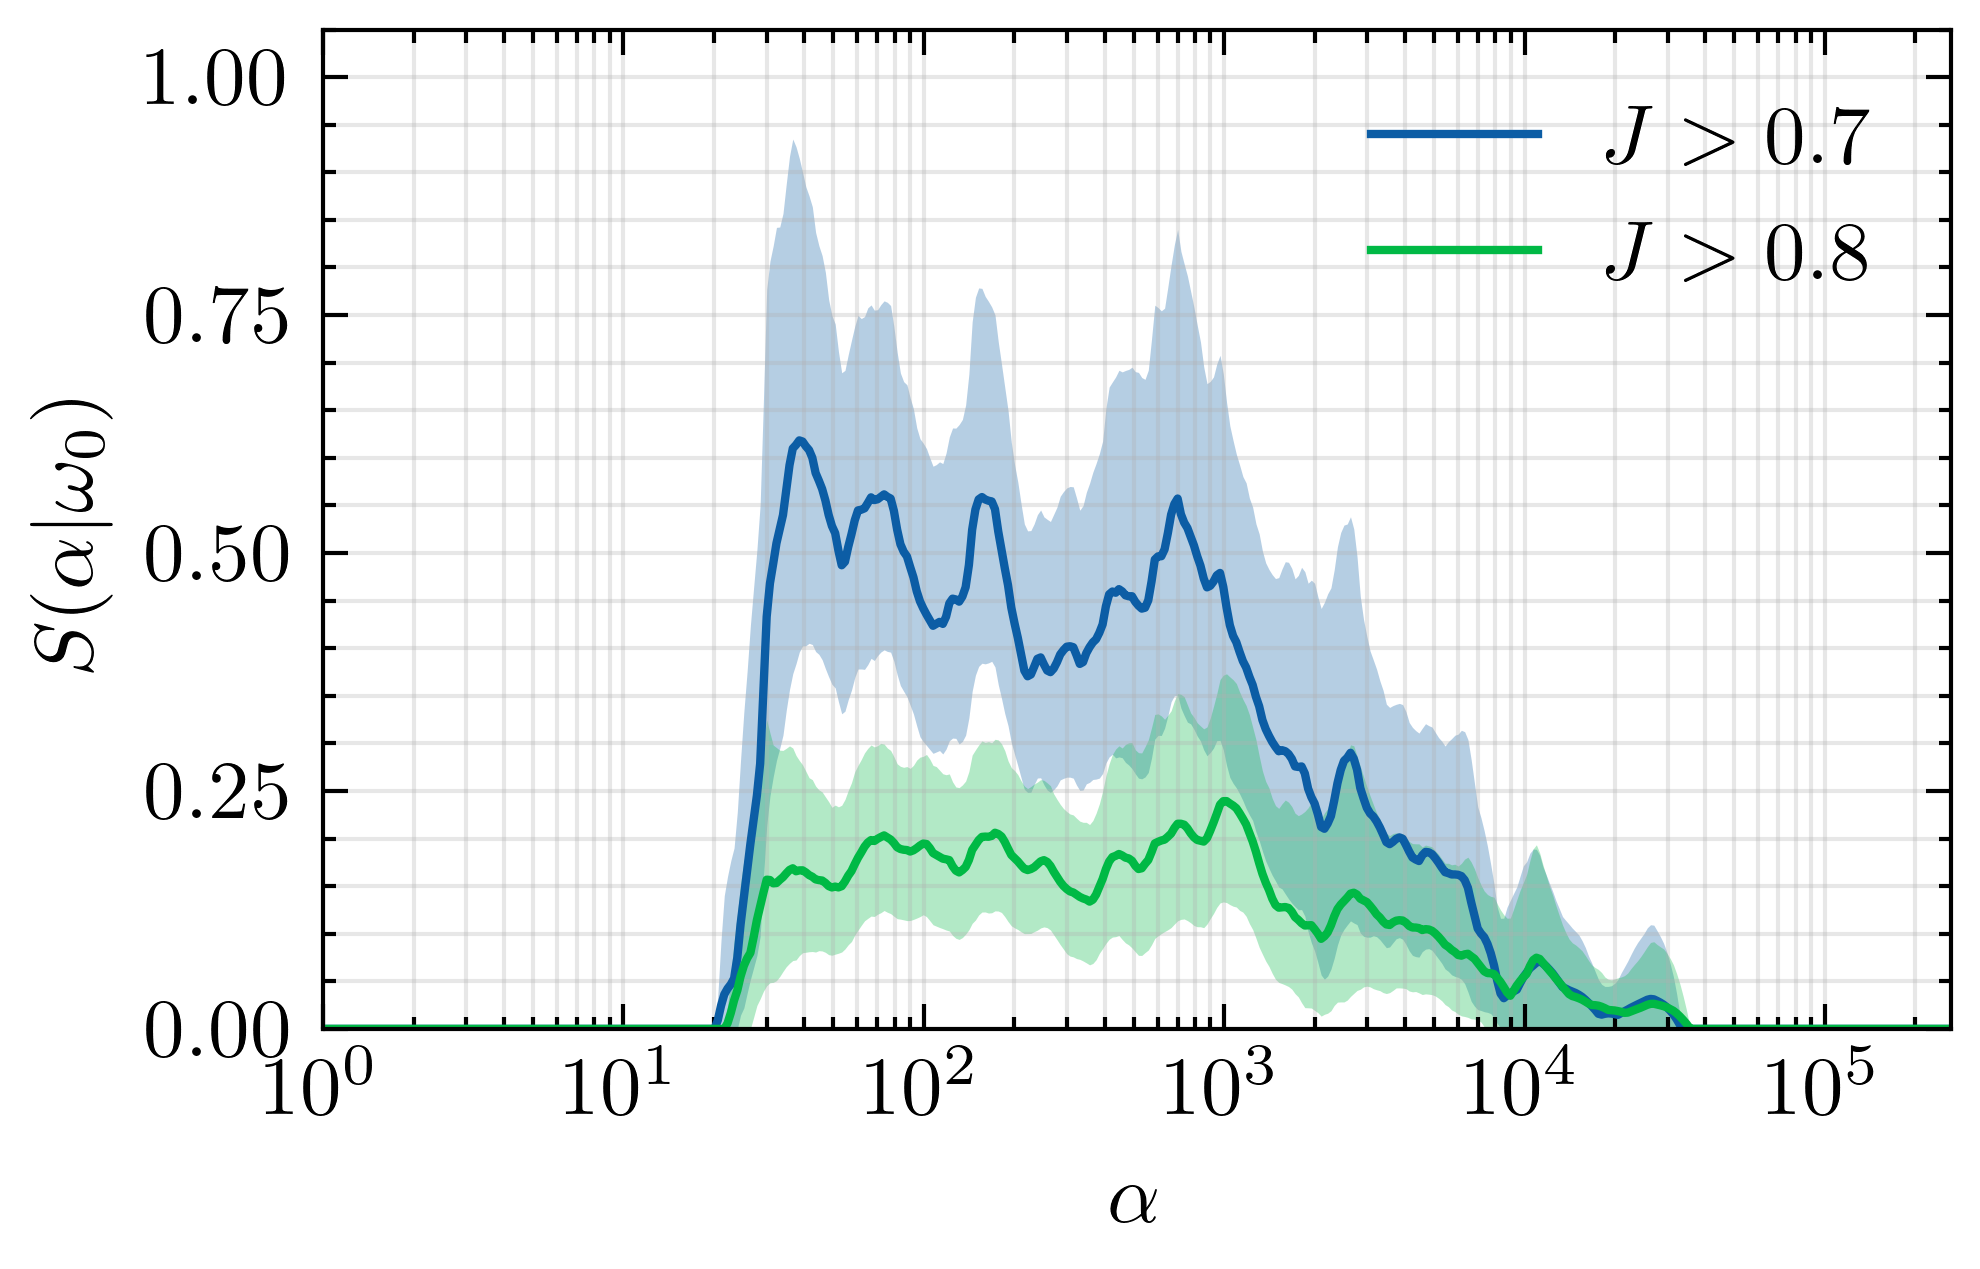

In [12]:
from joblib import Parallel, delayed

# 200 for normal runs 5_000 for publication
numb_bootstrap = 5_000
plotting_alphas = np.geomspace(1, 512**2, 500)

for c_code, j_min_plot in enumerate([0.7, 0.8]):
    
    bootstrap_kde_data = np.array(
        Parallel(n_jobs=-1, verbose = 1)(
            delayed(get_s_KDE)(
                j_min_plot,
                plotting_alphas,
                True,
                "scott"
            )
            for _ in range(numb_bootstrap)
        )
    ).T

    # Statistics
    mean_pdf = bootstrap_kde_data.mean(axis=1)
    lower = np.percentile(bootstrap_kde_data, 2.5, axis=1)
    upper = np.percentile(bootstrap_kde_data, 97.5, axis=1)

    # 95% confidence interval
    plt.fill_between(
        plotting_alphas, lower, upper,
        alpha=0.3,
        color= f"C{c_code}",
        linewidth = 0
    )

    # Mean bootstrap KsDE
    plt.plot(plotting_alphas, mean_pdf, label=rf"$J > {j_min_plot}$", c = f"C{c_code}")

plt.xscale("log")
# plt.yscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$S(\alpha|\omega_0)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.savefig("S_from_manual_detection.png")
plt.show()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 404 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1404 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 2804 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 4604 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 4957 out of 5000 | elapsed:    9.5s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    9.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 404 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1404 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 2804 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 4604 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 4957 out of 5000 | elapsed:   10.8s 

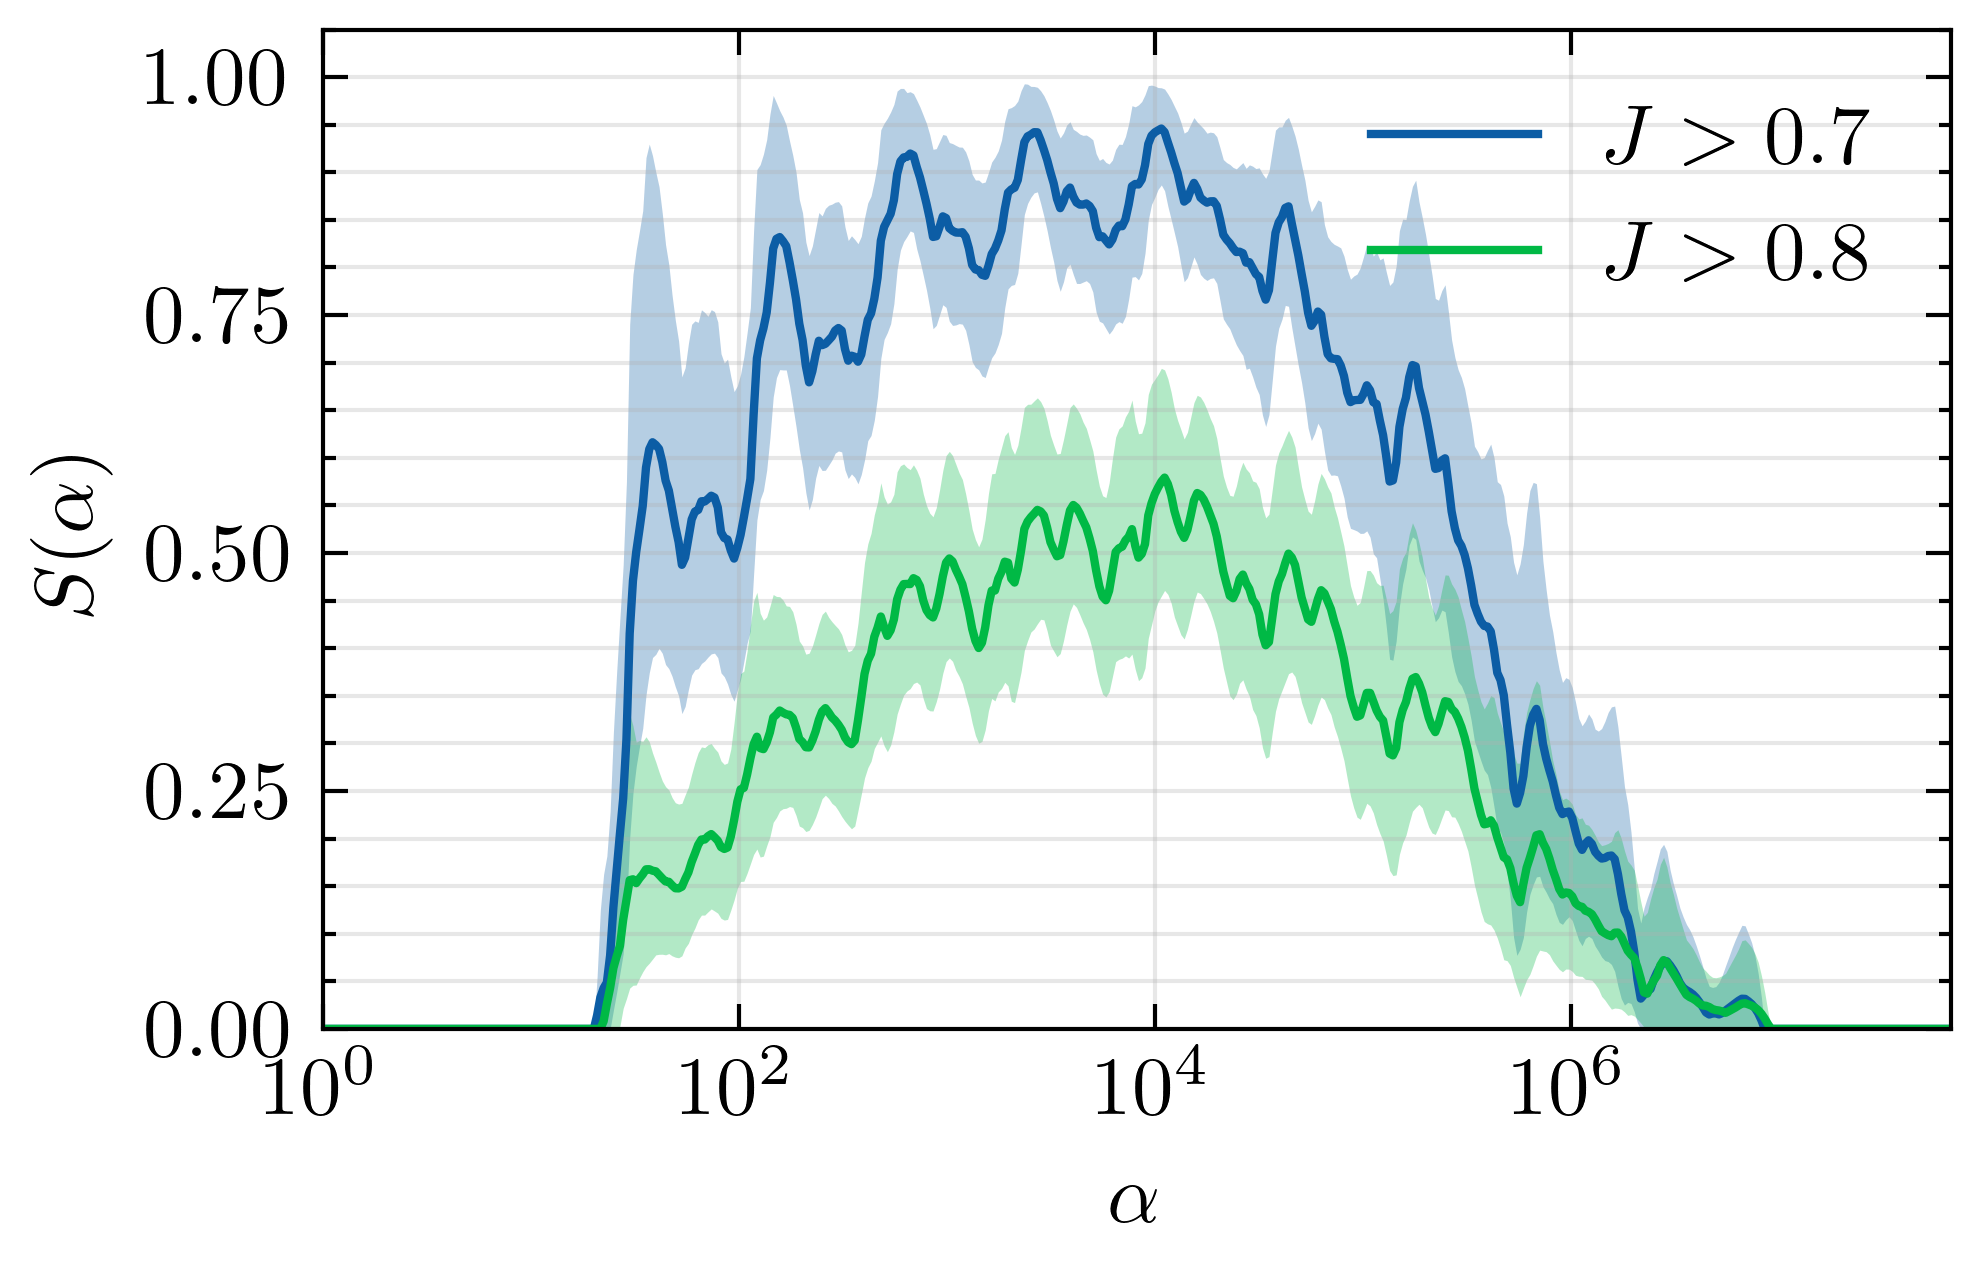

In [17]:
from joblib import Parallel, delayed

# 200 for normal runs 5_000 for publication
numb_bootstrap = 5_000
plotting_alphas = np.geomspace(1, 2 ** (2 * 4) * 512**2, 500)

def get_s_alpha_KDE(j_min: float,
    alpha_inputs: np.ndarray,
    bootstrap: bool = False,
    bw_method: float = 0.1):
    return 1 - np.prod([
            1 - get_s_KDE(j_min, alpha_inputs / (2 ** (2 * 4 - 2 * i)), bootstrap, bw_method) for i in range(5)
        ], axis=0)

for c_code, j_min_plot in enumerate([0.7, 0.8]):
    
    bootstrap_kde_data = np.array(
        Parallel(n_jobs=-1, verbose = 1)(
            delayed(get_s_alpha_KDE)(
                j_min_plot,
                plotting_alphas,
                True,
                "scott"
            )
            for _ in range(numb_bootstrap)
        )
    ).T

    # Statistics
    mean_pdf = bootstrap_kde_data.mean(axis=1)
    lower = np.percentile(bootstrap_kde_data, 2.5, axis=1)
    upper = np.percentile(bootstrap_kde_data, 97.5, axis=1)

    # 95% confidence interval
    plt.fill_between(
        plotting_alphas, lower, upper,
        alpha=0.3,
        color= f"C{c_code}",
        linewidth = 0
    )

    # Mean bootstrap KsDE
    plt.plot(plotting_alphas, mean_pdf, label=rf"$J > {j_min_plot}$", c = f"C{c_code}")

plt.xscale("log")
# plt.yscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, plotting_alphas.max())
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$S(\alpha)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.savefig("S_alpha_from_manual_detection.png")
plt.show()

In [8]:
# import numpy as np
# import matplotlib.pyplot as plt

# db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
# alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
# j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

# auto_alphas = dp.boulder_agg_data.collect().with_columns(
#     (pl.col("alpha") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size")
# )["viewport_size"]

# plotting_alphas = np.geomspace(1, 512**2, 500)
# plotting_alphas_log = np.log(plotting_alphas)

# alphas_pass = alphas[j > 0.7]

# log_alphas = np.log(alphas)
# log_alphas_pass = np.log(alphas_pass)
# # log_auto_alphas = np.log(auto_alphas)

# log_alphas_kde = lambda alpha : len(log_alphas) * gaussian_kde(log_alphas)(np.log(alpha)) / alpha
# log_alphas_pass_kde = lambda alpha : len(log_alphas_pass) * gaussian_kde(log_alphas_pass)(np.log(alpha)) / alpha
# # log_auto_alphas_kde = lambda alpha : len(log_auto_alphas) * gaussian_kde(log_auto_alphas, bw_method = 0.01)(np.log(alpha)) / alpha

# plt.plot(plotting_alphas, log_alphas_kde(plotting_alphas), label="Total KDE")
# plt.plot(plotting_alphas, log_alphas_pass_kde(plotting_alphas), label="Success KDE")
# plt.xscale("log")
# plt.xlabel("Viewport size")
# plt.ylabel("Density")
# plt.legend()
# plt.show()